In [109]:
import pandas as pd
import pickle
import ast
import matplotlib.pyplot as plt

In [110]:
DISEASE = input("Disease: ")
DISEASE_FOLDER = f"../output/{DISEASE}/"
RESULT_FOLDER = DISEASE_FOLDER + "leiden_results"

In [111]:
with open(f"{RESULT_FOLDER}/result_communities_selected.pkl", "rb") as f:
    communities_selected = pickle.load(f)

In [112]:
important_terms = pd.read_csv(DISEASE_FOLDER + "important_terms.csv")

In [113]:
important_terms = important_terms.sort_values(
    by=["Community Index", "Adjusted P-value"],
    ascending=[True, True]
).reset_index(drop=True)

In [114]:
important_terms

,Community Index,Community Size,Term,Overlap,Adjusted P-value,Category,Gene_set,P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,GO_ID,Slim_IDs,Overlap (value),KEGG_ID
0,0,1281,RNA Binding (GO:0003723),178/1411,2.638040e-16,['binding'],GO_Molecular_Function_2023,4.121937e-19,0.0,0.0,2.288611,9.688328e+01,OTUD4;TCERG1;RPL31;SPPL2B;CISD2;NOC2L;MKI67;RR...,GO:0003723,{'GO:0005488'},0.126152,NaN
1,0,1281,Intracellular Non-Membrane-Bounded Organelle (...,146/1195,1.461745e-12,['cellular anatomical structure'],GO_Cellular_Component_2023,1.414592e-14,0.0,0.0,2.166796,6.909772e+01,FHOD1;SPPL2B;AUP1;NOC2L;RBPJ;MKI67;RRP8;RRP9;S...,GO:0043232,{'GO:0110165'},0.122176,NaN
2,0,1281,Golgi Membrane (GO:0000139),72/427,2.532686e-12,['cellular anatomical structure'],GO_Cellular_Component_2023,3.267982e-14,0.0,0.0,3.080670,9.566101e+01,GALNT12;SCARB2;GPSM1;GALNT11;GALNT14;ST6GALNAC...,GO:0000139,{'GO:0110165'},0.168618,NaN
3,0,1281,Bounding Membrane Of Organelle (GO:0098588),109/819,1.126636e-11,['cellular anatomical structure'],GO_Cellular_Component_2023,1.817155e-13,0.0,0.0,2.359012,6.920476e+01,SCARB2;GALNT12;GALNT11;GALNT14;KDELR1;PITPNB;S...,GO:0098588,{'GO:0110165'},0.133089,NaN
4,0,1281,Metabolism Of RNA R-HSA-8953854,95/666,1.133910e-10,['Metabolism of RNA'],Reactome_2022,1.168979e-13,0.0,0.0,2.545843,7.580877e+01,TUT7;DDX49;RPL31;DDX47;SPPL2A;DDX42;YBX1;WDR43...,NaN,NaN,0.142643,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1352,9,276,Sensory Perception R-HSA-9709957,259/616,0.000000e+00,['Sensory Perception'],Reactome_2022,0.000000e+00,0.0,0.0,826.504037,inf,OR7G2;OR11H2;OR11H1;OR11H4;OR52N1;OR2M5;OR2M4;...,NaN,NaN,0.420455,NaN
1353,9,276,Sensory Perception Of Smell (GO:0007608),137/230,2.829441e-206,['multicellular organismal process'],GO_Biological_Process_2023,1.664377e-207,0.0,0.0,208.048813,9.905738e+04,OR1C1;OR2M5;OR2M4;OR2T12;OR2T10;OR10AC1;OR2T11...,GO:0007608,{'GO:0032501'},0.595652,NaN
1354,9,276,Detection Of Chemical Stimulus Involved In Sen...,87/141,8.144379e-129,['response to stimulus'],GO_Biological_Process_2023,9.581623e-130,0.0,0.0,167.674897,4.981222e+04,OR10J1;OR2A1;OR4E2;OR10J3;OR4E1;OR10J5;OR10J4;...,GO:0050907,{'GO:0050896'},0.617021,NaN
1355,9,276,Detection Of Chemical Stimulus Involved In Sen...,86/139,1.364967e-127,['response to stimulus'],GO_Biological_Process_2023,2.408766e-128,0.0,0.0,167.994638,4.936552e+04,OR10J1;OR2A1;OR4E2;OR10J3;OR4E1;OR10J5;OR10J4;...,GO:0050911,{'GO:0050896'},0.618705,NaN


# Community deep dive

In [115]:
important_terms[important_terms['Community Index'] == 6]

,Community Index,Community Size,Term,Overlap,Adjusted P-value,Category,Gene_set,P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,GO_ID,Slim_IDs,Overlap (value),KEGG_ID
1230,6,1010,RNA Binding (GO:0003723),171/1411,3.110871e-25,['binding'],GO_Molecular_Function_2023,7.496074e-28,0.0,0.0,2.917500,182.221206,RPL4;EIF4A2;SRP19;EIF4A1;RPL3;RPL34;RRP1;HDLBP...,GO:0003723,{'GO:0005488'},0.121191,NaN
1231,6,1010,rRNA Processing R-HSA-72312,46/199,1.408460e-15,['Metabolism of RNA'],Reactome_2022,1.778359e-18,0.0,0.0,5.874908,240.112448,RPL4;RPL3;RPL34;NIP7;RPL12;WDR3;RPLP0;ISG20L2;...,NaN,NaN,0.231156,NaN
1232,6,1010,Translation R-HSA-72766,54/281,5.138154e-15,['Metabolism of proteins'],Reactome_2022,1.297514e-17,0.0,0.0,4.668875,181.542204,EIF4A2;RPL4;MRPS17;EIF4A1;SRP19;RPL3;MRPS16;RP...,NaN,NaN,0.192171,NaN
1233,6,1010,Major Pathway Of rRNA Processing In Nucleolus ...,41/179,4.858701e-14,['Metabolism of RNA'],Reactome_2022,1.840417e-16,0.0,0.0,5.780141,209.422419,RPL4;RPL3;RPL34;WDR3;NIP7;RPL12;RPLP0;ISG20L2;...,NaN,NaN,0.229050,NaN
1234,6,1010,Metabolism Of RNA R-HSA-8953854,87/666,5.377679e-14,['Metabolism of RNA'],Reactome_2022,2.715999e-16,0.0,0.0,2.997204,107.426405,RPL4;EIF4A2;EIF4A1;RPL3;NXT1;DDX46;RPL34;WDR3;...,NaN,NaN,0.130631,NaN
1235,6,1010,rRNA Processing In Nucleus And Cytosol R-HSA-8...,41/189,2.213908e-13,['Metabolism of RNA'],Reactome_2022,1.397669e-15,0.0,0.0,5.386732,184.247619,RPL4;RPL3;RPL34;WDR3;NIP7;RPL12;RPLP0;ISG20L2;...,NaN,NaN,0.216931,NaN
1236,6,1010,SRP-dependent Cotranslational Protein Targetin...,29/108,8.017615e-12,['Metabolism of proteins'],Reactome_2022,6.073951e-14,0.0,0.0,7.076466,215.352286,RPL4;SRP19;RPL3;RPL34;RPL12;RPLP0;RPL36A;MRPL1...,NaN,NaN,0.268519,NaN
1237,6,1010,Translation (GO:0006412),42/234,1.087206e-09,['cellular process'],GO_Biological_Process_2023,6.097622e-13,0.0,0.0,4.247998,119.477961,RPL4;MRPS17;RPL3;MRPS16;RPL34;RPL12;MRPL19;MRP...,GO:0006412,{'GO:0009987'},0.179487,NaN
1238,6,1010,L13a-mediated Translational Silencing Of Cerul...,26/108,2.069182e-09,['Metabolism of proteins'],Reactome_2022,1.828822e-11,0.0,0.0,6.092703,150.640637,EIF4A2;RPL4;EIF4A1;RPL3;RPL34;RPL12;RPLP0;RPL3...,NaN,NaN,0.240741,NaN
1239,6,1010,GTP Hydrolysis And Joining Of 60S Ribosomal Su...,26/109,2.265195e-09,['Metabolism of proteins'],Reactome_2022,2.288076e-11,0.0,0.0,6.018978,147.469332,EIF4A2;RPL4;EIF4A1;RPL3;RPL34;RPL12;RPLP0;RPL3...,NaN,NaN,0.238532,NaN


In [116]:
list(important_terms[(important_terms['Community Index'] == 7)]["Term"])

['Class A/1 (Rhodopsin-like Receptors) R-HSA-373076',
 'Signaling By GPCR R-HSA-372790',
 'GPCR Ligand Binding R-HSA-500792',
 'Double-Stranded DNA Binding (GO:0003690)',
 'Sequence-Specific DNA Binding (GO:0043565)',
 'GPCR Downstream Signaling R-HSA-388396',
 'Neuroactive ligand-receptor interaction',
 'Sequence-Specific Double-Stranded DNA Binding (GO:1990837)',
 'Peptide Ligand-Binding Receptors R-HSA-375276',
 'G Protein-Coupled Receptor Activity (GO:0004930)',
 'G Alpha (Q) Signaling Events R-HSA-416476',
 'G Alpha (I) Signaling Events R-HSA-418594',
 'Transcription Cis-Regulatory Region Binding (GO:0000976)',
 'Neuron Differentiation (GO:0030182)',
 'ADORA2B Mediated Anti-Inflammatory Cytokine Production R-HSA-9660821',
 'Neuropeptide Signaling Pathway (GO:0007218)',
 'GABA-A Receptor Activity (GO:0004890)',
 'Lysosphingolipid And LPA Receptors R-HSA-419408',
 'G Alpha (S) Signaling Events R-HSA-418555',
 'GABA-A Receptor Complex (GO:1902711)',
 'GABA Receptor Activity (GO:00169

# Community Category df

In [117]:
df = important_terms

# ---------------------------------------------------
# 1. Parse Category column (stringified list) -> list
# ---------------------------------------------------
df["Category"] = df["Category"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# ---------------------------------------------------
# 2. Explode: one category per row
# ---------------------------------------------------
df_exp = df.explode("Category").reset_index(drop=True)

# ---------------------------------------------------
# 3. Parse Overlap "a/b" into numerator and denominator
# ---------------------------------------------------
def parse_overlap(s):
    try:
        a, b = s.split("/")
        return int(a), int(b)
    except Exception:
        return 0, 0

overlap_nums = []
overlap_dens = []

for s in df_exp["Overlap"]:
    a, b = parse_overlap(s)
    overlap_nums.append(a)
    overlap_dens.append(b)

df_exp["Overlap_num"] = overlap_nums
df_exp["Overlap_den"] = overlap_dens

# ---------------------------------------------------
# 4. Total number of terms per community
# ---------------------------------------------------
total_terms = (
    df_exp.groupby("Community Index")["Term"]
          .nunique()
)

# ---------------------------------------------------
# 5. Aggregate per (Community Index, Category)
#    - count = # of distinct terms
#    - Gross Overlap = (sum a_i) / (sum b_i)
# ---------------------------------------------------
agg = (
    df_exp.groupby(["Community Index", "Category"])
    .agg(
        count=("Term", "nunique"),
        sum_a=("Overlap_num", "sum"),
        sum_b=("Overlap_den", "sum"),
    )
    .reset_index()
)

agg["Gross Overlap"] = agg["sum_a"] / agg["sum_b"]

# ---------------------------------------------------
# 6. Add total_terms_in_comm and frac_of_comm
# ---------------------------------------------------
agg["total_terms_in_comm"] = agg["Community Index"].map(total_terms)
agg["frac_of_comm"] = agg["count"] / agg["total_terms_in_comm"]

# ---------------------------------------------------
# 7. Final output df
# ---------------------------------------------------
community_categories = agg[[
    "Community Index",
    "Category",
    "count",
    "Gross Overlap",
    "total_terms_in_comm",
    "frac_of_comm",
]]

community_categories = community_categories.sort_values(
    by=["Community Index", "count"],
    ascending=[True, False]
).reset_index(drop=True)

community_categories


,Community Index,Category,count,Gross Overlap,total_terms_in_comm,frac_of_comm
0,0,cellular process,27,0.165351,88,0.306818
1,0,cellular anatomical structure,18,0.135250,88,0.204545
2,0,localization,14,0.179316,88,0.159091
3,0,Metabolism of RNA,6,0.179205,88,0.068182
4,0,biological regulation,5,0.217184,88,0.056818
...,...,...,...,...,...,...
96,9,Sensory Perception,3,0.551064,9,0.333333
97,9,multicellular organismal process,2,0.582353,9,0.222222
98,9,response to stimulus,2,0.617857,9,0.222222
99,9,Sensory system,1,0.606818,9,0.111111


## heatmap

In [118]:
heat_df = community_categories.pivot(
    index="Community Index",
    columns="Category",
    values="Gross Overlap"
)


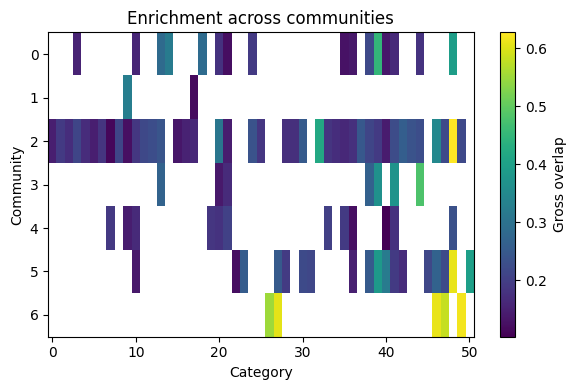

In [119]:
plt.figure(figsize=(6, 4))
plt.imshow(heat_df, aspect="auto")
plt.colorbar(label="Gross overlap")
plt.xlabel("Category")
plt.ylabel("Community")
plt.title("Enrichment across communities")
plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/community_category_heatmap.png")
plt.show()

## filtering top categories

In [120]:
community_categories_filtered = (
    community_categories.sort_values(["Community Index", "count"], ascending=[True, False])
          .groupby("Community Index")
          .head(5)
          .reset_index(drop=True)
)

In [121]:
community_categories_filtered

,Community Index,Category,count,Gross Overlap,total_terms_in_comm,frac_of_comm
0,0,cellular process,27,0.165351,88,0.306818
1,0,cellular anatomical structure,18,0.135250,88,0.204545
2,0,localization,14,0.179316,88,0.159091
3,0,Metabolism of RNA,6,0.179205,88,0.068182
4,0,biological regulation,5,0.217184,88,0.056818
5,2,Developmental Biology,2,0.326241,3,0.666667
6,2,Infectious disease: viral,1,0.118474,3,0.333333
7,3,biological regulation,417,0.212915,1114,0.374327
8,3,cellular process,214,0.224896,1114,0.192101
9,3,binding,55,0.175000,1114,0.049372


In [122]:
from reportlab.lib.pagesizes import letter, landscape
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle
from reportlab.lib import colors

def df_to_pdf(df, filename="output.pdf"):
    pdf = SimpleDocTemplate(
        filename,
        pagesize=landscape(letter)
    )

    # Convert DF to 2D list
    data = [df.columns.tolist()] + df.values.tolist()

    # Create table
    table = Table(data)

    # Styling
    style = TableStyle([
        ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
        ("TEXTCOLOR", (0,0), (-1,0), colors.black),
        ("ALIGN", (0,0), (-1,-1), "CENTER"),
        ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
        ("FONTSIZE", (0,0), (-1,-1), 8),
        ("BOTTOMPADDING", (0,0), (-1,0), 8),
        ("GRID", (0,0), (-1,-1), 0.25, colors.black),
    ])
    table.setStyle(style)

    elements = [table]
    pdf.build(elements)
    print(f"PDF saved to {filename}")


## output to pdf

In [123]:
community_categories_filtered

,Community Index,Category,count,Gross Overlap,total_terms_in_comm,frac_of_comm
0,0,cellular process,27,0.165351,88,0.306818
1,0,cellular anatomical structure,18,0.135250,88,0.204545
2,0,localization,14,0.179316,88,0.159091
3,0,Metabolism of RNA,6,0.179205,88,0.068182
4,0,biological regulation,5,0.217184,88,0.056818
5,2,Developmental Biology,2,0.326241,3,0.666667
6,2,Infectious disease: viral,1,0.118474,3,0.333333
7,3,biological regulation,417,0.212915,1114,0.374327
8,3,cellular process,214,0.224896,1114,0.192101
9,3,binding,55,0.175000,1114,0.049372


In [124]:
df_to_pdf(community_categories_filtered, f"../../Graphs/{DISEASE}/community_categories_filtered.pdf")

PDF saved to ../../Graphs/SCHIZOPHRENIA/community_categories_filtered.pdf


# Community Count Dict

In [125]:
category_count_by_comm = {}

for _, row in community_categories.iterrows():
    comm = row["Community Index"]
    cat = row["Category"]
    count = row["count"]
    gross = row["Gross Overlap"]

    if comm not in category_count_by_comm:
        category_count_by_comm[comm] = {}

    # insertion happens in sorted order because community_categories is sorted
    category_count_by_comm[comm][cat] = (count, gross)


In [126]:
for i in range(len(communities_selected)):
    if i not in category_count_by_comm.keys():
        category_count_by_comm[i] = {}

In [127]:
category_count_by_comm

{0: {'cellular process': (27, 0.1653509707702155),
  'cellular anatomical structure': (18, 0.1352498288843258),
  'localization': (14, 0.1793160967472894),
  'Metabolism of RNA': (6, 0.17920540997464074),
  'biological regulation': (5, 0.2171837708830549),
  'binding': (4, 0.1365139348134152),
  'Metabolism of proteins': (3, 0.12083105522143248),
  'Vesicle-mediated transport': (3, 0.1277346506704305),
  'Cell Cycle': (2, 0.15371024734982333),
  'Disease': (2, 0.15835777126099707),
  'Organelle biogenesis and maintenance': (2, 0.19081272084805653),
  'protein-containing complex': (2, 0.3953488372093023),
  'Gene expression (Transcription)': (1, 0.2835820895522388),
  'Glycan biosynthesis and metabolism': (1, 0.32),
  'Lipid metabolism': (1, 0.2857142857142857),
  'catalytic activity': (1, 0.45)},
 2: {'Developmental Biology': (2, 0.3262411347517731),
  'Infectious disease: viral': (1, 0.11847389558232932)},
 3: {'biological regulation': (417, 0.21291470434327578),
  'cellular process':

In [128]:
with open(f"{DISEASE_FOLDER}/category_count_by_comm.pkl", "wb") as f:
    pickle.dump(category_count_by_comm, f)